<a href="https://colab.research.google.com/github/putriekasfr/P240441100087_Putri-Eka-Safira_TugasCNN_PraktikumB/blob/main/240441100087_Putri%20Eka%20Safira_TugasCNN_PraktikumB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BAGIAN B - PRAKTIKUM IMPLEMENTASI CNN**                                       

---
**B1. DATASET DAN SETUP**
1. Import Libray

pada tahap awal dilakukan import beberapa libray yang diperlukan. TensorFlow digunakan sebagai framework utama untuk membangun dan melatih model CNN. Numpy yang digunakan untuk pengolahan array dan data numerik, sedangkan Metplotlib digunakan untuk menampilkan gambar dan visualisasi hasil.


In [10]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from IPython.display import display, Image

2. Menentukan Random Seed

random seed digunakan agar proses yang melibatkan pengacakan data dapat menghasilkan kondisi yang relatif sama ketika program dijalankan kembali. di praktikumB ini digunakan nilai seed 42 untuk python, Numpy, dan TensorFlow.

In [11]:
# ================================================================
# B.1 — DATASET DAN SETUP
# ================================================================

print("\n")
print("=" * 70)
print("B.1 — DATASET DAN SETUP")
print("=" * 70)


# ================================================================
# 1. RANDOM SEED
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)



B.1 — DATASET DAN SETUP


3. Mengecek TensorFlow dan perangkat

pengecekan versi TensorFlow serta perangkat yang digunakan untuk proses komputasi, yang dimana jika google colab menyediakan GPU maka proses training dapat berjalan lebih cepat dan apalabila GPU tidak tersedia, proses dapat dilakukan menggunakan CPU.

In [12]:
# ================================================================
# 2. CEK TENSORFLOW DAN GPU
# ================================================================

print("TensorFlow Version :", tf.__version__)

gpu = tf.config.list_physical_devices("GPU")

if gpu:
    print("Device            : GPU")
    print("GPU               :", gpu[0].name)
else:
    print("Device            : CPU")

TensorFlow Version : 2.20.0
Device            : CPU


4. Menentukan Hyperparameter

Hyperparameter yaitu parameter yang ditentukan sebelum proses training. pada praktikum ini digunakan batch size 128, 10 epoch, dan learning rate 0,001. Nilai Hyperparameter digunakan pada model A dan model B, sehingga perbandingan kedua model lebih adil. Hal tersebu sesuai ketentuan B.2 yang meminta kedua model dilatih pada dataset dan Hyperparameter yang identik.


In [13]:
# ================================================================
# 3. HYPERPARAMETER
#
# Digunakan SAMA pada Model A dan Model B
# agar perbandingan adil.
# ================================================================

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001


print("\nHyperparameter")
print("-" * 40)

print("Batch Size    :", BATCH_SIZE)
print("Epoch         :", EPOCHS)
print("Learning Rate :", LEARNING_RATE)


Hyperparameter
----------------------------------------
Batch Size    : 128
Epoch         : 10
Learning Rate : 0.001


5. Pengolahan Dataset Fashion-MNIST

Pada tahap ini, dataset Fashion-MNIST dimuat menggunakan tf.keras.datasets.fashion_mnist.load_data() yang secara otomatis menyediakan data training dan testing. Nilai piksel gambar yang awalnya berada pada rentang 0–255 kemudian dinormalisasi menjadi 0–1 agar proses training model lebih stabil dan efisien. Karena Fashion-MNIST merupakan gambar grayscale berukuran 28 × 28 piksel, ditambahkan satu dimensi channel sehingga bentuk data menjadi 28 × 28 × 1 agar sesuai dengan format input layer CNN. Data training kemudian dibagi lagi menjadi 50.000 data training dan 10.000 data validation, sedangkan 10.000 data testing tetap digunakan untuk evaluasi akhir model. Setelah dataset selesai dipersiapkan, beberapa contoh gambar Fashion-MNIST ditampilkan untuk melihat bentuk data yang akan digunakan pada proses training. Program menampilkan 15 gambar dalam susunan 3 baris × 5 kolom, lengkap dengan nama kelas dari masing-masing gambar.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Informasi Dataset Fashion-MNIST
---------------------------------------------
Jumlah Data Training   : 50000
Jumlah Data Validation : 10000
Jumlah Data Testing    : 10000
Ukuran Gambar          : (28, 28, 1)
Jumlah Kelas           : 10


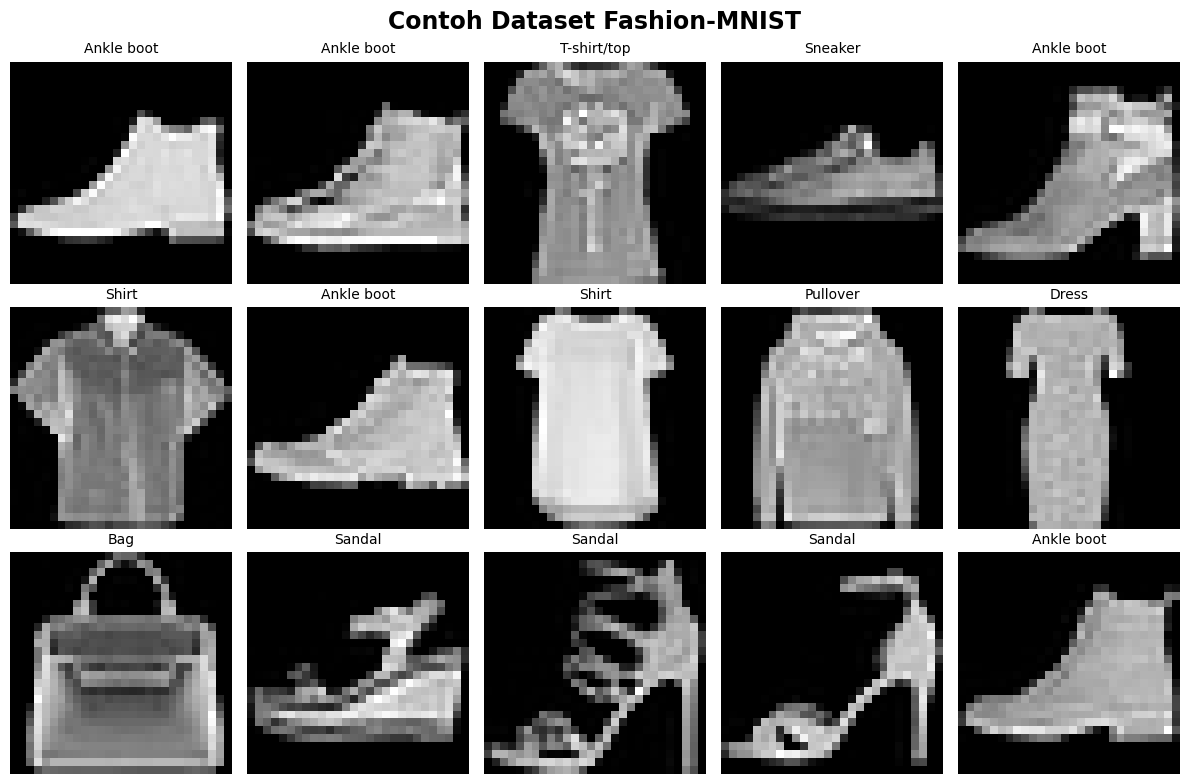

In [14]:
# ================================================================
# 4. LOAD DATASET FASHION-MNIST
# ================================================================

(x_train_full, y_train_full), (x_test, y_test) = (
    tf.keras.datasets.fashion_mnist.load_data()
)


# ================================================================
# 5. NORMALISASI DATA
#
# Nilai pixel awal 0-255
# diubah menjadi 0-1
# ================================================================

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ================================================================
# 6. TAMBAH CHANNEL
#
# Awal :
# (28, 28)
#
# Menjadi :
# (28, 28, 1)
# ================================================================

x_train_full = np.expand_dims(
    x_train_full,
    axis=-1
)

x_test = np.expand_dims(
    x_test,
    axis=-1
)


# ================================================================
# 7. SPLIT TRAINING DAN VALIDATION
#
# Fashion-MNIST:
# 60.000 data training
# 10.000 data testing
#
# Training dibagi:
# 50.000 training
# 10.000 validation
# ================================================================

x_train, x_val, y_train, y_val = train_test_split(

    x_train_full,
    y_train_full,

    test_size=10000,

    random_state=SEED,

    stratify=y_train_full
)


# ================================================================
# 8. NAMA KELAS FASHION-MNIST
# ================================================================

class_names = [

    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


# ================================================================
# 9. INFORMASI DATASET
# ================================================================

print("\nInformasi Dataset Fashion-MNIST")
print("-" * 45)

print("Jumlah Data Training   :", len(x_train))
print("Jumlah Data Validation :", len(x_val))
print("Jumlah Data Testing    :", len(x_test))

print("Ukuran Gambar          :", x_train.shape[1:])
print("Jumlah Kelas           :", len(class_names))

# ================================================================
# 10. VISUALISASI DATASET
#
# GAMBAR HASIL CODING
# ================================================================

plt.figure(figsize=(12, 8))

for i in range(15):

    plt.subplot(
        3,
        5,
        i + 1
    )

    plt.imshow(
        x_train[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        class_names[y_train[i]],
        fontsize=10
    )

    plt.axis("off")


plt.suptitle(
    "Contoh Dataset Fashion-MNIST",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# RINGKASAN
Pada tahap dataset dan setup, digunakan framework TensorFlow/Keras dengan dataset Fashion-MNIST. Proses awal meliputi penentuan random seed, pengecekan perangkat komputasi, serta penetapan hyperparameter berupa batch size 128, 10 epoch, dan learning rate 0,001. Dataset kemudian dinormalisasi dari rentang piksel 0–255 menjadi 0–1, ditambahkan dimensi channel menjadi 28 × 28 × 1, lalu data training dibagi menjadi 50.000 data training dan 10.000 data validation, sementara 10.000 data testing digunakan untuk evaluasi akhir. Fashion-MNIST memiliki 10 kelas, dan beberapa contoh gambar divisualisasikan untuk memastikan data telah berhasil diproses sebelum digunakan pada tahap implementasi model.


---
B.2 - Implementasi Model
1. Model A — Custom CNN

Model A merupakan Custom CNN yang terdiri dari tiga blok utama. Setiap blok menggunakan Conv2D, ReLU, dan MaxPooling2D. Jumlah filter bertambah secara bertahap dari 32, 64, hingga 128. Setelah tiga blok convolution selesai, hasil feature map diubah menjadi satu dimensi menggunakan Flatten, kemudian diteruskan ke fully connected layer dengan 128 neuron. Layer output menggunakan 10 neuron dengan aktivasi Softmax karena Fashion-MNIST memiliki 10 kelas.



In [15]:
def create_custom_cnn():

    inputs = layers.Input(
        shape=(28, 28, 1),
        name="Input_FashionMNIST"
    )
    # ------------------------------------------------------------
    # BLOK 1
    # ------------------------------------------------------------

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        name="Conv_Block_1"
    )(inputs)

    x = layers.ReLU(
        name="ReLU_Block_1"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPooling_Block_1"
    )(x)


    # ------------------------------------------------------------
    # BLOK 2
    # ------------------------------------------------------------

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        name="Conv_Block_2"
    )(x)

    x = layers.ReLU(
        name="ReLU_Block_2"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPooling_Block_2"
    )(x)


    # ------------------------------------------------------------
    # BLOK 3
    # ------------------------------------------------------------

    x = layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        name="Conv_Block_3"
    )(x)

    x = layers.ReLU(
        name="ReLU_Block_3"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPooling_Block_3"
    )(x)


    # ------------------------------------------------------------
    # FLATTEN
    # ------------------------------------------------------------

    x = layers.Flatten(
        name="Flatten"
    )(x)


    # ------------------------------------------------------------
    # FULLY CONNECTED
    # ------------------------------------------------------------

    x = layers.Dense(
        128,
        activation="relu",
        name="Fully_Connected"
    )(x)


    # ------------------------------------------------------------
    # OUTPUT SOFTMAX
    # ------------------------------------------------------------

    outputs = layers.Dense(
        10,
        activation="softmax",
        name="Output_Softmax"
    )(x)


    model = models.Model(

        inputs=inputs,
        outputs=outputs,

        name="MODEL_A_CUSTOM_CNN"
    )


    return model


# ================================================================
# MEMBUAT MODEL A
# ================================================================

model_A = create_custom_cnn()


print("\n")
print("=" * 70)
print("MODEL A — CUSTOM CNN")
print("=" * 70)

model_A.summary()



MODEL A — CUSTOM CNN


Model: "MODEL_A_CUSTOM_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_FashionMNIST (InputLayer) │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Block_1 (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_Block_1 (ReLU)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling_Block_1              │ (None, 14, 14, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Block_2 (Conv2D)           │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_Block_2 (ReLU)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling_Block_2              │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Block_3 (Conv2D)           │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_Block_3 (ReLU)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling_Block_3              │ (None, 3, 3, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fully_Connected (Dense)         │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

2. Residual Block untuk Model B

Model B menggunakan residual connection. Pada residual block, input awal disimpan sebagai shortcut, kemudian input diproses melalui dua layer convolution yang disertai BatchNormalization dan ReLU. Setelah itu, hasil convolution dijumlahkan kembali dengan shortcut menggunakan layers.Add().

Jika ukuran feature map atau jumlah channel berubah, shortcut terlebih dahulu disesuaikan menggunakan convolution berukuran 1 × 1. Konsep utama residual connection pada kode ini adalah F(x) + x.

In [16]:
# ================================================================
# 11. RESIDUAL BLOCK
# ================================================================

def residual_block(
    x,
    filters,
    stride=1,
    block_name="Residual_Block"
):


    # ------------------------------------------------------------
    # SIMPAN INPUT SEBAGAI SHORTCUT
    # ------------------------------------------------------------

    shortcut = x


    # ------------------------------------------------------------
    # CONVOLUTION PERTAMA
    # ------------------------------------------------------------

    x = layers.Conv2D(

        filters=filters,

        kernel_size=(3, 3),

        strides=stride,

        padding="same",

        use_bias=False,

        name=f"{block_name}_Conv1"

    )(x)


    x = layers.BatchNormalization(

        name=f"{block_name}_BN1"

    )(x)


    x = layers.ReLU(

        name=f"{block_name}_ReLU1"

    )(x)


    # ------------------------------------------------------------
    # CONVOLUTION KEDUA
    # ------------------------------------------------------------

    x = layers.Conv2D(

        filters=filters,

        kernel_size=(3, 3),

        strides=1,

        padding="same",

        use_bias=False,

        name=f"{block_name}_Conv2"

    )(x)


    x = layers.BatchNormalization(

        name=f"{block_name}_BN2"

    )(x)


    # ------------------------------------------------------------
    # MENYESUAIKAN SHORTCUT
    #
    # Jika jumlah channel atau ukuran feature map berubah
    # ============================================================

    if stride != 1 or int(shortcut.shape[-1]) != filters:


        shortcut = layers.Conv2D(

            filters=filters,

            kernel_size=(1, 1),

            strides=stride,

            padding="same",

            use_bias=False,

            name=f"{block_name}_Shortcut_Conv"

        )(shortcut)


        shortcut = layers.BatchNormalization(

            name=f"{block_name}_Shortcut_BN"

        )(shortcut)


    # ------------------------------------------------------------
    # RESIDUAL CONNECTION
    #
    # F(x) + x
    # ------------------------------------------------------------

    x = layers.Add(

        name=f"{block_name}_ADD"

    )([x, shortcut])


    x = layers.ReLU(

        name=f"{block_name}_Output_ReLU"

    )(x)


    return x

Kode ini mendefinisikan residual block pada Model B. Input diproses melalui dua layer convolution lalu dijumlahkan kembali dengan shortcut. Pada tahap ini belum ada output karena fungsi baru didefinisikan dan akan digunakan saat membangun Mini ResNet.

3. Model B — Mini ResNet

Model B dibangun menggunakan Mini ResNet. Model diawali dengan convolution awal berjumlah 32 filter, kemudian dilanjutkan dengan empat residual block. Jumlah filter yang digunakan bertahap yaitu 32, 64, 64, dan 128.

Pada beberapa residual block digunakan stride=2 untuk memperkecil ukuran feature map. Setelah seluruh residual block selesai, digunakan GlobalAveragePooling2D, kemudian hasilnya diteruskan ke output layer dengan 10 neuron dan aktivasi Softmax.

In [17]:
# ================================================================
# 12. MEMBUAT MODEL B — MINI RESNET
# ================================================================

def create_mini_resnet():


    inputs = layers.Input(

        shape=(28, 28, 1),

        name="Input_FashionMNIST"
    )


    # ------------------------------------------------------------
    # INITIAL CONVOLUTION
    # ------------------------------------------------------------

    x = layers.Conv2D(

        filters=32,

        kernel_size=(3, 3),

        padding="same",

        use_bias=False,

        name="Initial_Conv"

    )(inputs)


    x = layers.BatchNormalization(

        name="Initial_BN"

    )(x)


    x = layers.ReLU(

        name="Initial_ReLU"

    )(x)


    # ------------------------------------------------------------
    # RESIDUAL BLOCK 1
    # ------------------------------------------------------------

    x = residual_block(

        x,

        filters=32,

        stride=1,

        block_name="Residual_Block_1"
    )


    # ------------------------------------------------------------
    # RESIDUAL BLOCK 2
    # ------------------------------------------------------------

    x = residual_block(

        x,

        filters=64,

        stride=2,

        block_name="Residual_Block_2"
    )


    # ------------------------------------------------------------
    # RESIDUAL BLOCK 3
    # ------------------------------------------------------------

    x = residual_block(

        x,

        filters=64,

        stride=1,

        block_name="Residual_Block_3"
    )


    # ------------------------------------------------------------
    # RESIDUAL BLOCK 4
    # ------------------------------------------------------------

    x = residual_block(

        x,

        filters=128,

        stride=2,

        block_name="Residual_Block_4"
    )


    # ------------------------------------------------------------
    # GLOBAL AVERAGE POOLING
    # ------------------------------------------------------------

    x = layers.GlobalAveragePooling2D(

        name="Global_Average_Pooling"

    )(x)


    # ------------------------------------------------------------
    # OUTPUT SOFTMAX
    # ------------------------------------------------------------

    outputs = layers.Dense(

        10,

        activation="softmax",

        name="Output_Softmax"

    )(x)


    model = models.Model(

        inputs=inputs,

        outputs=outputs,

        name="MODEL_B_MINI_RESNET"
    )


    return model


# ================================================================
# MEMBUAT MODEL B
# ================================================================

model_B = create_mini_resnet()


print("\n")
print("=" * 70)
print("MODEL B — MINI RESNET")
print("=" * 70)

model_B.summary()



MODEL B — MINI RESNET


Model: "MODEL_B_MINI_RESNET"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_FashionMNIST  │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Initial_Conv        │ (None, 28, 28,    │        288 │ Input_FashionMNI… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Initial_BN          │ (None, 28, 28,    │        128 │ Initial_Conv[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Initial_ReLU (ReLU) │ (None, 28, 28,    │          0 │ Initial_BN[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_C… │ (None, 28, 28,    │      9,216 │ Initial_ReLU[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_B… │ (None, 28, 28,    │        128 │ Residual_Block_1… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_R… │ (None, 28, 28,    │          0 │ Residual_Block_1… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_C… │ (None, 28, 28,    │      9,216 │ Residual_Block_1… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_B… │ (None, 28, 28,    │        128 │ Residual_Block_1… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_A… │ (None, 28, 28,    │          0 │ Residual_Block_1… │
│ (Add)               │ 32)               │            │ Initial_ReLU[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_1_O… │ (None, 28, 28,    │          0 │ Residual_Block_1… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_2_C… │ (None, 14, 14,    │     18,432 │ Residual_Block_1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_2_B… │ (None, 14, 14,    │        256 │ Residual_Block_2… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_2_R… │ (None, 14, 14,    │          0 │ Residual_Block_2… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_2_C… │ (None, 14, 14,    │     36,864 │ Residual_Block_2… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_2_S… │ (None, 14, 14,    │      2,048 │ Residual_Block_1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Block_2_B… │ (None, 14, 14,    │        256 │ Residual_Block_2

 Total params: 383,658 (1.46 MB)

 Trainable params: 382,058 (1.46 MB)

 Non-trainable params: 1,600 (6.25 KB)

4. Menghitung Jumlah Parameter

Setelah kedua model berhasil dibuat, jumlah parameter dihitung menggunakan fungsi count_params(). Jumlah parameter ini digunakan untuk mengetahui ukuran dan kompleksitas masing-masing model serta nantinya menjadi salah satu komponen perbandingan pada tahap evaluasi.

In [18]:
# ================================================================
# 13. JUMLAH PARAMETER
# ================================================================

parameter_A = model_A.count_params()

parameter_B = model_B.count_params()


print("\n")
print("=" * 70)
print("JUMLAH PARAMETER")
print("=" * 70)


print(
    f"Model A — Custom CNN  : {parameter_A:,}"
)

print(
    f"Model B — Mini ResNet : {parameter_B:,}"
)



JUMLAH PARAMETER
Model A — Custom CNN  : 241,546
Model B — Mini ResNet : 383,658


# Ringkasan B.2
Pada tahap implementasi model dibuat dua arsitektur CNN. Model A menggunakan Custom CNN dengan tiga blok Conv2D–ReLU–MaxPooling, sedangkan Model B menggunakan Mini ResNet dengan residual connection. Setelah kedua arsitektur terbentuk, jumlah parameter masing-masing model dihitung sebagai salah satu dasar perbandingan sebelum masuk ke tahap training dan evaluasi pada B.3.

---
B.3 — Eksperimen dan Evaluasi
1. Compile Model A & Training Model A

Model A dikompilasi menggunakan optimizer Adam, learning rate 0.001, loss sparse_categorical_crossentropy, dan metrik accuracy.


In [19]:
# ================================================================
# 14. COMPILE MODEL A
# ================================================================

model_A.compile(

    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)
# ================================================================
# 15. TRAINING MODEL A
# ================================================================

print("\n")
print("=" * 70)
print("TRAINING MODEL A — CUSTOM CNN")
print("=" * 70)


start_A = time.time()


history_A = model_A.fit(

    x_train,
    y_train,

    validation_data=(
        x_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


training_time_A = (
    time.time() - start_A
)


print("\nTraining Model A selesai")

print(
    f"Waktu Training : {training_time_A:.2f} detik"
)

print(
    f"                : {training_time_A / 60:.2f} menit"
)



TRAINING MODEL A — CUSTOM CNN
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 210ms/step - accuracy: 0.7930 - loss: 0.5690 - val_accuracy: 0.8770 - val_loss: 0.3500
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 212ms/step - accuracy: 0.8783 - loss: 0.3350 - val_accuracy: 0.8924 - val_loss: 0.2991
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 209ms/step - accuracy: 0.8956 - loss: 0.2852 - val_accuracy: 0.9017 - val_loss: 0.2750
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - accuracy: 0.9072 - loss: 0.2543 - val_accuracy: 0.9016 - val_loss: 0.2667
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - accuracy: 0.9160 - loss: 0.2291 - val_accuracy: 0.9030 - val_loss: 0.2655
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 218ms/step - accuracy: 0.9245 - loss: 0.2064 - val_accuracy: 0.9061 - val_loss: 0.2645
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 212ms/step - accuracy: 0.9316 - loss: 0.1877 - val_accuracy: 0.9104 - val_loss: 0.2562
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms

Model A dilatih menggunakan data training dan validation selama 10 epoch dengan batch size 128. Waktu training juga dihitung untuk mengetahui lama proses pelatihan.

2. Compile Model B & Training Model B

Model B menggunakan optimizer, learning rate, loss, dan metrik yang sama dengan Model A agar perbandingan kedua model lebih adil.


In [20]:
# ================================================================
# 16. COMPILE MODEL B
#
# Hyperparameter SAMA dengan Model A
# ================================================================

model_B.compile(

    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

# ================================================================
# 17. TRAINING MODEL B
# ================================================================

print("\n")
print("=" * 70)
print("TRAINING MODEL B — MINI RESNET")
print("=" * 70)


start_B = time.time()


history_B = model_B.fit(

    x_train,
    y_train,

    validation_data=(
        x_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


training_time_B = (
    time.time() - start_B
)


print("\nTraining Model B selesai")

print(
    f"Waktu Training : {training_time_B:.2f} detik"
)

print(
    f"                : {training_time_B / 60:.2f} menit"
)



TRAINING MODEL B — MINI RESNET
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 577s 1s/step - accuracy: 0.8330 - loss: 0.4668 - val_accuracy: 0.1321 - val_loss: 4.0570
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.8958 - loss: 0.2862 - val_accuracy: 0.7625 - val_loss: 0.6769
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.9159 - loss: 0.2344 - val_accuracy: 0.7313 - val_loss: 0.9051
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 621s 1s/step - accuracy: 0.9286 - loss: 0.2009 - val_accuracy: 0.8540 - val_loss: 0.4572
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 574s 1s/step - accuracy: 0.9377 - loss: 0.1750 - val_accuracy: 0.8654 - val_loss: 0.4664
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.9450 - loss: 0.1534 - val_accuracy: 0.8834 - val_loss: 0.3842
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 640s 2s/step - accuracy: 0.9539 - loss: 0.1296 - val_accuracy: 0.8973 - val_loss: 0.3069
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 619s 2s/step - accuracy:

Model B dilatih menggunakan data dan hyperparameter yang sama dengan Model A. Waktu training juga dicatat untuk dibandingkan.

3. Grafik Loss Model A

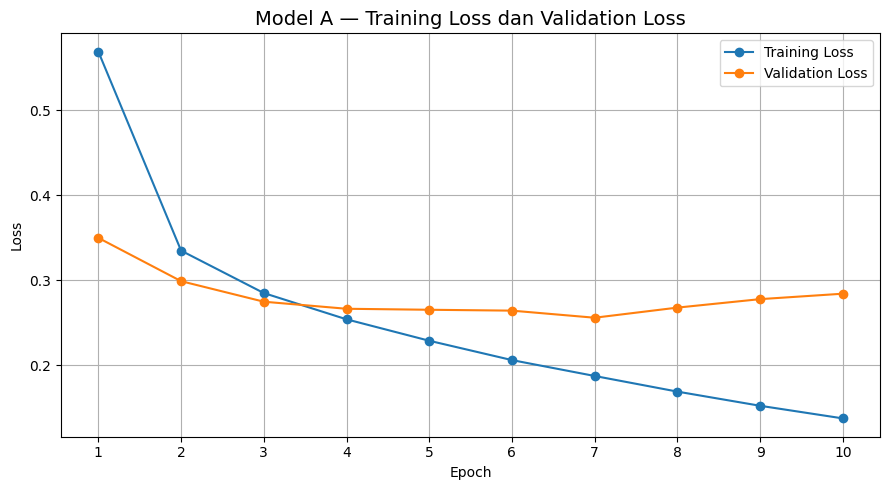

In [22]:
# ================================================================
# 18. GRAFIK MODEL A
#
# TRAINING LOSS vs VALIDATION LOSS
# ================================================================

epoch_range_A = range(
    1,
    len(history_A.history["loss"]) + 1
)


plt.figure(figsize=(9, 5))


plt.plot(

    epoch_range_A,

    history_A.history["loss"],

    marker="o",

    label="Training Loss"
)


plt.plot(

    epoch_range_A,

    history_A.history["val_loss"],

    marker="o",

    label="Validation Loss"
)


plt.title(
    "Model A — Training Loss dan Validation Loss",
    fontsize=14
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(epoch_range_A)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

Grafik menunjukkan perubahan training loss dan validation loss Model A pada setiap epoch.

4. Grafik Accuracy Model A

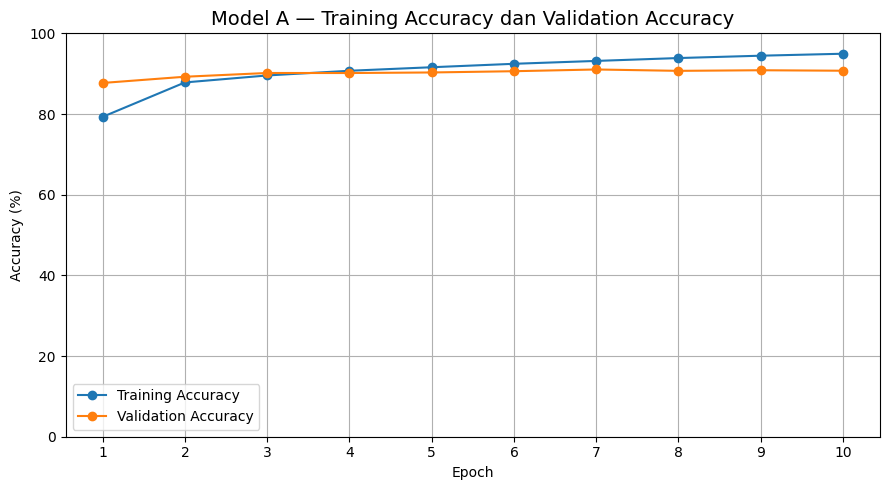

In [23]:
# ================================================================
# 19. GRAFIK ACCURACY MODEL A
#
# TRAINING ACCURACY vs VALIDATION ACCURACY
# ================================================================

plt.figure(figsize=(9, 5))


plt.plot(

    epoch_range_A,

    np.array(
        history_A.history["accuracy"]
    ) * 100,

    marker="o",

    label="Training Accuracy"
)


plt.plot(

    epoch_range_A,

    np.array(
        history_A.history["val_accuracy"]
    ) * 100,

    marker="o",

    label="Validation Accuracy"
)


plt.title(
    "Model A — Training Accuracy dan Validation Accuracy",
    fontsize=14
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.xticks(epoch_range_A)

plt.ylim(0, 100)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

Grafik menunjukkan perkembangan training accuracy dan validation accuracy Model A selama proses training.

5. Grafik Loss Model B & Grafik Accuracy Model B

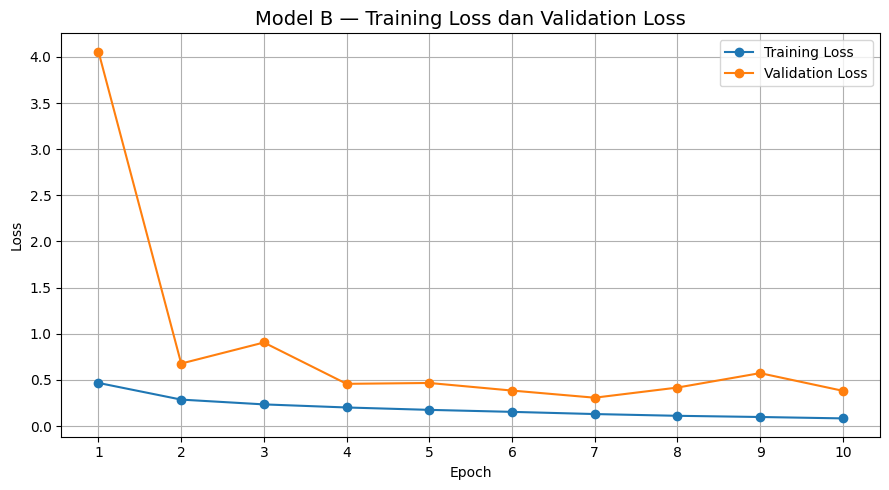

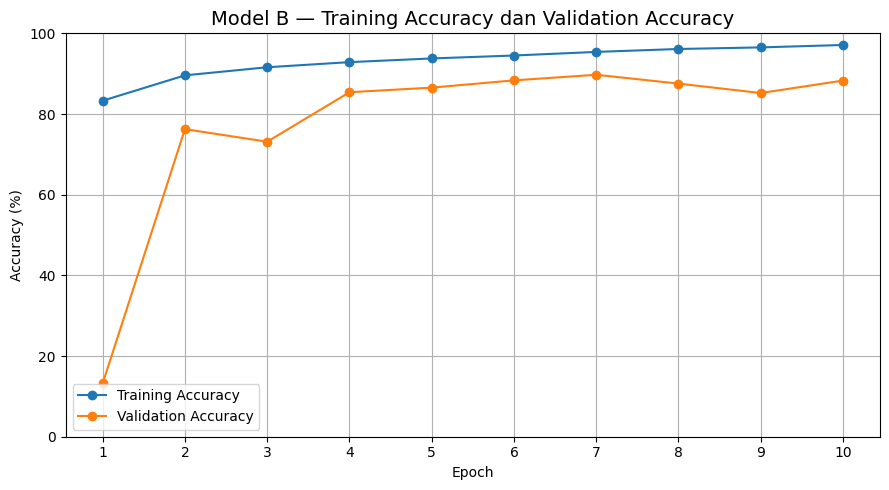

In [24]:
# ================================================================
# 20. GRAFIK LOSS MODEL B
# ================================================================

epoch_range_B = range(
    1,
    len(history_B.history["loss"]) + 1
)


plt.figure(figsize=(9, 5))


plt.plot(

    epoch_range_B,

    history_B.history["loss"],

    marker="o",

    label="Training Loss"
)


plt.plot(

    epoch_range_B,

    history_B.history["val_loss"],

    marker="o",

    label="Validation Loss"
)


plt.title(
    "Model B — Training Loss dan Validation Loss",
    fontsize=14
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.xticks(epoch_range_B)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# ================================================================
# 21. GRAFIK ACCURACY MODEL B
# ================================================================

plt.figure(figsize=(9, 5))


plt.plot(

    epoch_range_B,

    np.array(
        history_B.history["accuracy"]
    ) * 100,

    marker="o",

    label="Training Accuracy"
)


plt.plot(

    epoch_range_B,

    np.array(
        history_B.history["val_accuracy"]
    ) * 100,

    marker="o",

    label="Validation Accuracy"
)


plt.title(
    "Model B — Training Accuracy dan Validation Accuracy",
    fontsize=14
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.xticks(epoch_range_B)

plt.ylim(0, 100)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

Grafik menunjukkan perubahan training loss dan validation loss Model B selama proses training dan perkembangan training accuracy dan validation accuracy Model B.

6. Evaluasi Test Set

In [25]:
# ================================================================
# 22. EVALUASI TEST SET
# ================================================================

test_loss_A, test_accuracy_A = model_A.evaluate(

    x_test,
    y_test,

    verbose=0
)


test_loss_B, test_accuracy_B = model_B.evaluate(

    x_test,
    y_test,

    verbose=0
)


print("\n")
print("=" * 70)
print("HASIL EVALUASI TEST SET")
print("=" * 70)


print("\nMODEL A — CUSTOM CNN")

print(
    f"Test Loss     : {test_loss_A:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy_A * 100:.2f}%"
)


print("\nMODEL B — MINI RESNET")

print(
    f"Test Loss     : {test_loss_B:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy_B * 100:.2f}%"
)



HASIL EVALUASI TEST SET

MODEL A — CUSTOM CNN
Test Loss     : 0.2988
Test Accuracy : 89.93%

MODEL B — MINI RESNET
Test Loss     : 0.4131
Test Accuracy : 87.69%


Kedua model diuji menggunakan data testing untuk memperoleh test loss dan test accuracy sebagai hasil akhir performa model.

7. Prediksi Data Test

Model melakukan prediksi terhadap data testing, kemudian kelas dengan nilai probabilitas tertinggi dipilih sebagai hasil prediksi.


In [26]:
# ================================================================
# 23. PREDIKSI DATA TEST
# ================================================================

probability_A = model_A.predict(
    x_test,
    verbose=0
)

probability_B = model_B.predict(
    x_test,
    verbose=0
)


prediksi_A = np.argmax(
    probability_A,
    axis=1
)

prediksi_B = np.argmax(
    probability_B,
    axis=1
)

8. Confusion Matrix Model A

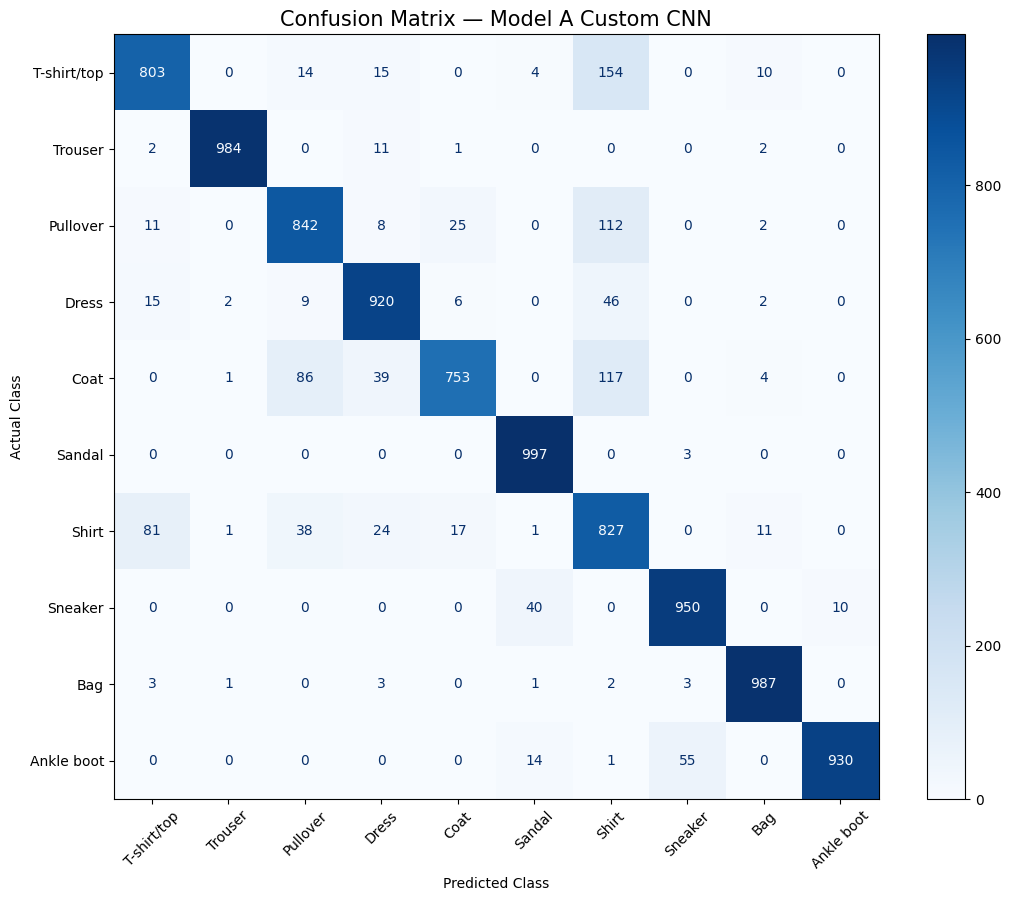

In [27]:
# ================================================================
# 24. CONFUSION MATRIX MODEL A
#
# INI KOTAK-KOTAK HASIL PREDIKSI MODEL A
# ================================================================

cm_A = confusion_matrix(
    y_test,
    prediksi_A
)


fig, ax = plt.subplots(
    figsize=(11, 9)
)


disp_A = ConfusionMatrixDisplay(

    confusion_matrix=cm_A,

    display_labels=class_names
)


disp_A.plot(

    cmap="Blues",

    xticks_rotation=45,

    values_format="d",

    ax=ax
)


plt.title(
    "Confusion Matrix — Model A Custom CNN",
    fontsize=15
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


plt.tight_layout()

plt.show()

Confusion matrix menunjukkan jumlah prediksi benar dan salah Model A pada masing-masing kelas Fashion-MNIST. Nilai diagonal menunjukkan prediksi yang benar.

9. Confusion Matrix Model B

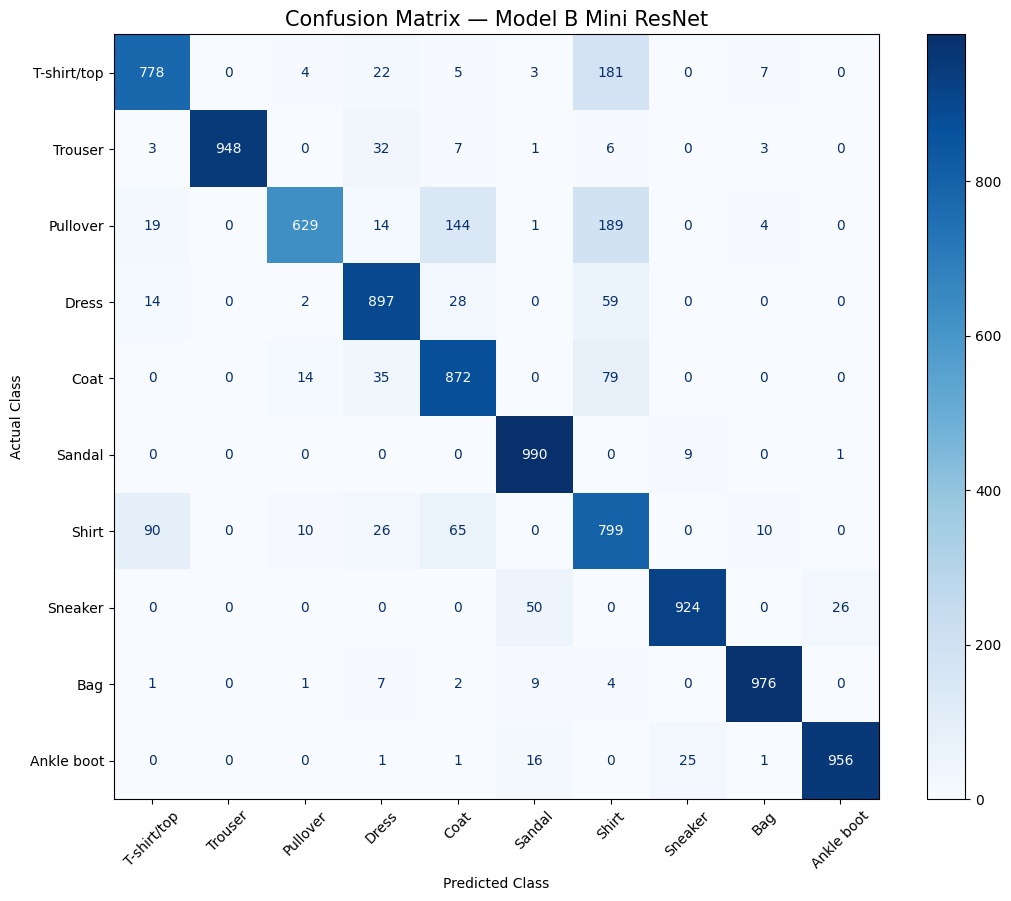

In [28]:
# ================================================================
# 25. CONFUSION MATRIX MODEL B
#
# INI KOTAK-KOTAK HASIL PREDIKSI MODEL B
# ================================================================

cm_B = confusion_matrix(
    y_test,
    prediksi_B
)


fig, ax = plt.subplots(
    figsize=(11, 9)
)


disp_B = ConfusionMatrixDisplay(

    confusion_matrix=cm_B,

    display_labels=class_names
)


disp_B.plot(

    cmap="Blues",

    xticks_rotation=45,

    values_format="d",

    ax=ax
)


plt.title(
    "Confusion Matrix — Model B Mini ResNet",
    fontsize=15
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


plt.tight_layout()

plt.show()

Confusion matrix Model B digunakan untuk melihat hasil klasifikasi Mini ResNet pada setiap kelas.

10. Tabel Perbandingan Kedua Model

Tabel membandingkan test accuracy, jumlah parameter, serta waktu training Model A dan Model B.



In [29]:
# ================================================================
# 30. TABEL PERBANDINGAN MODEL
# ================================================================

hasil = pd.DataFrame({

    "Model": [

        "Model A - Custom CNN",

        "Model B - Mini ResNet"
    ],


    "Test Accuracy (%)": [

        round(
            test_accuracy_A * 100,
            2
        ),

        round(
            test_accuracy_B * 100,
            2
        )
    ],


    "Jumlah Parameter": [

        parameter_A,

        parameter_B
    ],


    "Waktu Training (detik)": [

        round(
            training_time_A,
            2
        ),

        round(
            training_time_B,
            2
        )
    ],


    "Waktu Training (menit)": [

        round(
            training_time_A / 60,
            2
        ),

        round(
            training_time_B / 60,
            2
        )
    ]
})


print("\n")
print("=" * 70)
print("TABEL PERBANDINGAN MODEL A DAN MODEL B")
print("=" * 70)


display(hasil)



TABEL PERBANDINGAN MODEL A DAN MODEL B


,Model,Test Accuracy (%),Jumlah Parameter,Waktu Training (detik),Waktu Training (menit)
0,Model A - Custom CNN,89.93,241546,944.03,15.73
1,Model B - Mini ResNet,87.69,383658,6024.11,100.40


11. Grafik Perbandingan Waktu Training

Grafik menunjukkan perbandingan waktu yang dibutuhkan kedua model selama proses training.

---



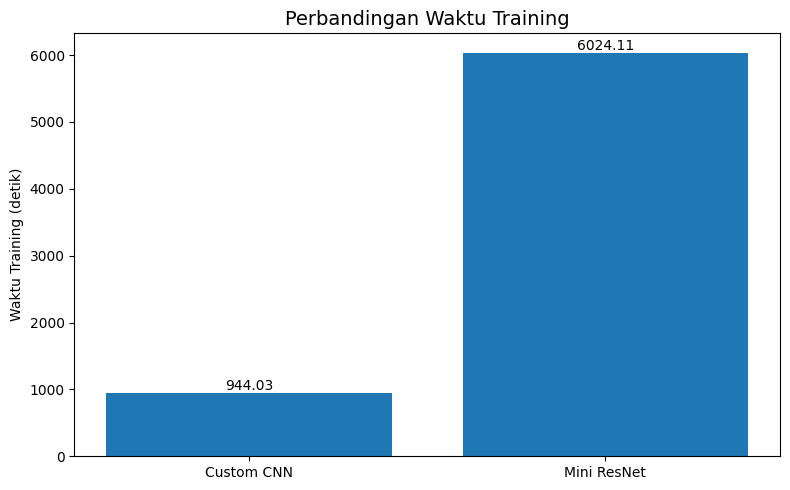

In [31]:
# ================================================================
# 33. GRAFIK PERBANDINGAN WAKTU TRAINING
# ================================================================

waktu_training = [

    training_time_A,

    training_time_B
]


plt.figure(figsize=(8, 5))


bars = plt.bar(

    nama_model,

    waktu_training
)


plt.title(
    "Perbandingan Waktu Training",
    fontsize=14
)


plt.ylabel(
    "Waktu Training (detik)"
)


for bar, nilai in zip(
    bars,
    waktu_training
):


    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{nilai:.2f}",

        ha="center",

        va="bottom"
    )


plt.tight_layout()

plt.show()

12. Ringkasan Hasil B.3


In [33]:
# ================================================================
# 34. RINGKASAN HASIL AKHIR B.3
# ================================================================

print("\n")
print("=" * 70)
print("RINGKASAN HASIL EKSPERIMEN B.3")
print("=" * 70)


print("\nMODEL A — CUSTOM CNN")

print(
    f"Test Accuracy    : {test_accuracy_A * 100:.2f}%"
)

print(
    f"Jumlah Parameter : {parameter_A:,}"
)

print(
    f"Waktu Training   : {training_time_A:.2f} detik "
    f"({training_time_A/60:.2f} menit)"
)


print("\nMODEL B — MINI RESNET")

print(
    f"Test Accuracy    : {test_accuracy_B * 100:.2f}%"
)

print(
    f"Jumlah Parameter : {parameter_B:,}"
)

print(
    f"Waktu Training   : {training_time_B:.2f} detik "
    f"({training_time_B/60:.2f} menit)"
)


# ================================================================
# MODEL DENGAN AKURASI TERBAIK
# ================================================================

if test_accuracy_A > test_accuracy_B:

    print(
        "\nModel dengan Test Accuracy lebih tinggi:"
        "\nMODEL A — CUSTOM CNN"
    )


elif test_accuracy_B > test_accuracy_A:

    print(
        "\nModel dengan Test Accuracy lebih tinggi:"
        "\nMODEL B — MINI RESNET"
    )


else:

    print(
        "\nKedua model memiliki Test Accuracy yang sama."
    )






RINGKASAN HASIL EKSPERIMEN B.3

MODEL A — CUSTOM CNN
Test Accuracy    : 89.93%
Jumlah Parameter : 241,546
Waktu Training   : 944.03 detik (15.73 menit)

MODEL B — MINI RESNET
Test Accuracy    : 87.69%
Jumlah Parameter : 383,658
Waktu Training   : 6024.11 detik (100.40 menit)

Model dengan Test Accuracy lebih tinggi:
MODEL A — CUSTOM CNN


Berdasarkan praktikum yang telah dilakukan, dataset Fashion-MNIST berhasil dipersiapkan melalui proses normalisasi, penambahan channel, pembagian data training dan validation, serta visualisasi data. Selanjutnya dibangun dua model, yaitu Model A Custom CNN dengan tiga blok Conv2D–ReLU–MaxPooling dan Model B Mini ResNet yang menggunakan residual connection. Kedua model kemudian dilatih dan dievaluasi menggunakan dataset serta hyperparameter yang sama. Hasil evaluasi dibandingkan berdasarkan training dan validation loss, training dan validation accuracy, waktu training, serta confusion matrix, sehingga dapat diketahui perbedaan performa dan efisiensi dari kedua arsitektur tersebut.